# Ecommerce sales data analysis and profit prediction Model

In [29]:
# Import all the libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from matplotlib.ticker import FuncFormatter
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder


# Extract the data
df=pd.read_csv(r"C:\Users\USER\OneDrive\Desktop\Ecommerce_Sales_Data_2024_2025.csv")
print(df.head(5))
df.info()
df.describe()

   Order ID  Order Date Customer Name Region       City   Category  \
0     10001  2024-10-19  Kashvi Varty  South  Bangalore      Books   
1     10002  2025-08-30   Advik Desai  North      Delhi  Groceries   
2     10003  2023-11-04    Rhea Kalla   East      Patna    Kitchen   
3     10004  2025-05-23     Anika Sen   East    Kolkata  Groceries   
4     10005  2025-01-19   Akarsh Kaul   West       Pune   Clothing   

  Sub-Category       Product Name  Quantity  Unit Price  Discount     Sales  \
0  Non-Fiction  Non-Fiction Ipsum         2       36294         5   68958.6   
1         Rice          Rice Nemo         1       42165        20   33732.0   
2       Juicer        Juicer Odio         4       64876        20  207603.2   
3          Oil      Oil Doloribus         5       37320        15  158610.0   
4    Kids Wear      Kids Wear Quo         1       50037        10   45033.3   

     Profit Payment Mode  
0  10525.09   Debit Card  
1   6299.66   Debit Card  
2  19850.27  Credit Car

,Order ID,Quantity,Unit Price,Discount,Sales,Profit
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,12500.500000,2.992600,39760.904600,10.051000,106733.204870,15941.746982
std,1443.520003,1.413133,22831.783946,7.084662,85108.208202,14897.684916
min,10001.000000,1.000000,222.000000,0.000000,264.100000,19.120000
25%,11250.750000,2.000000,20312.250000,5.000000,39766.537500,4892.295000
50%,12500.500000,3.000000,39459.500000,10.000000,83080.325000,11108.525000
75%,13750.250000,4.000000,59721.750000,15.000000,156968.587500,22467.987500
max,15000.000000,5.000000,79998.000000,20.000000,398485.000000,89688.440000


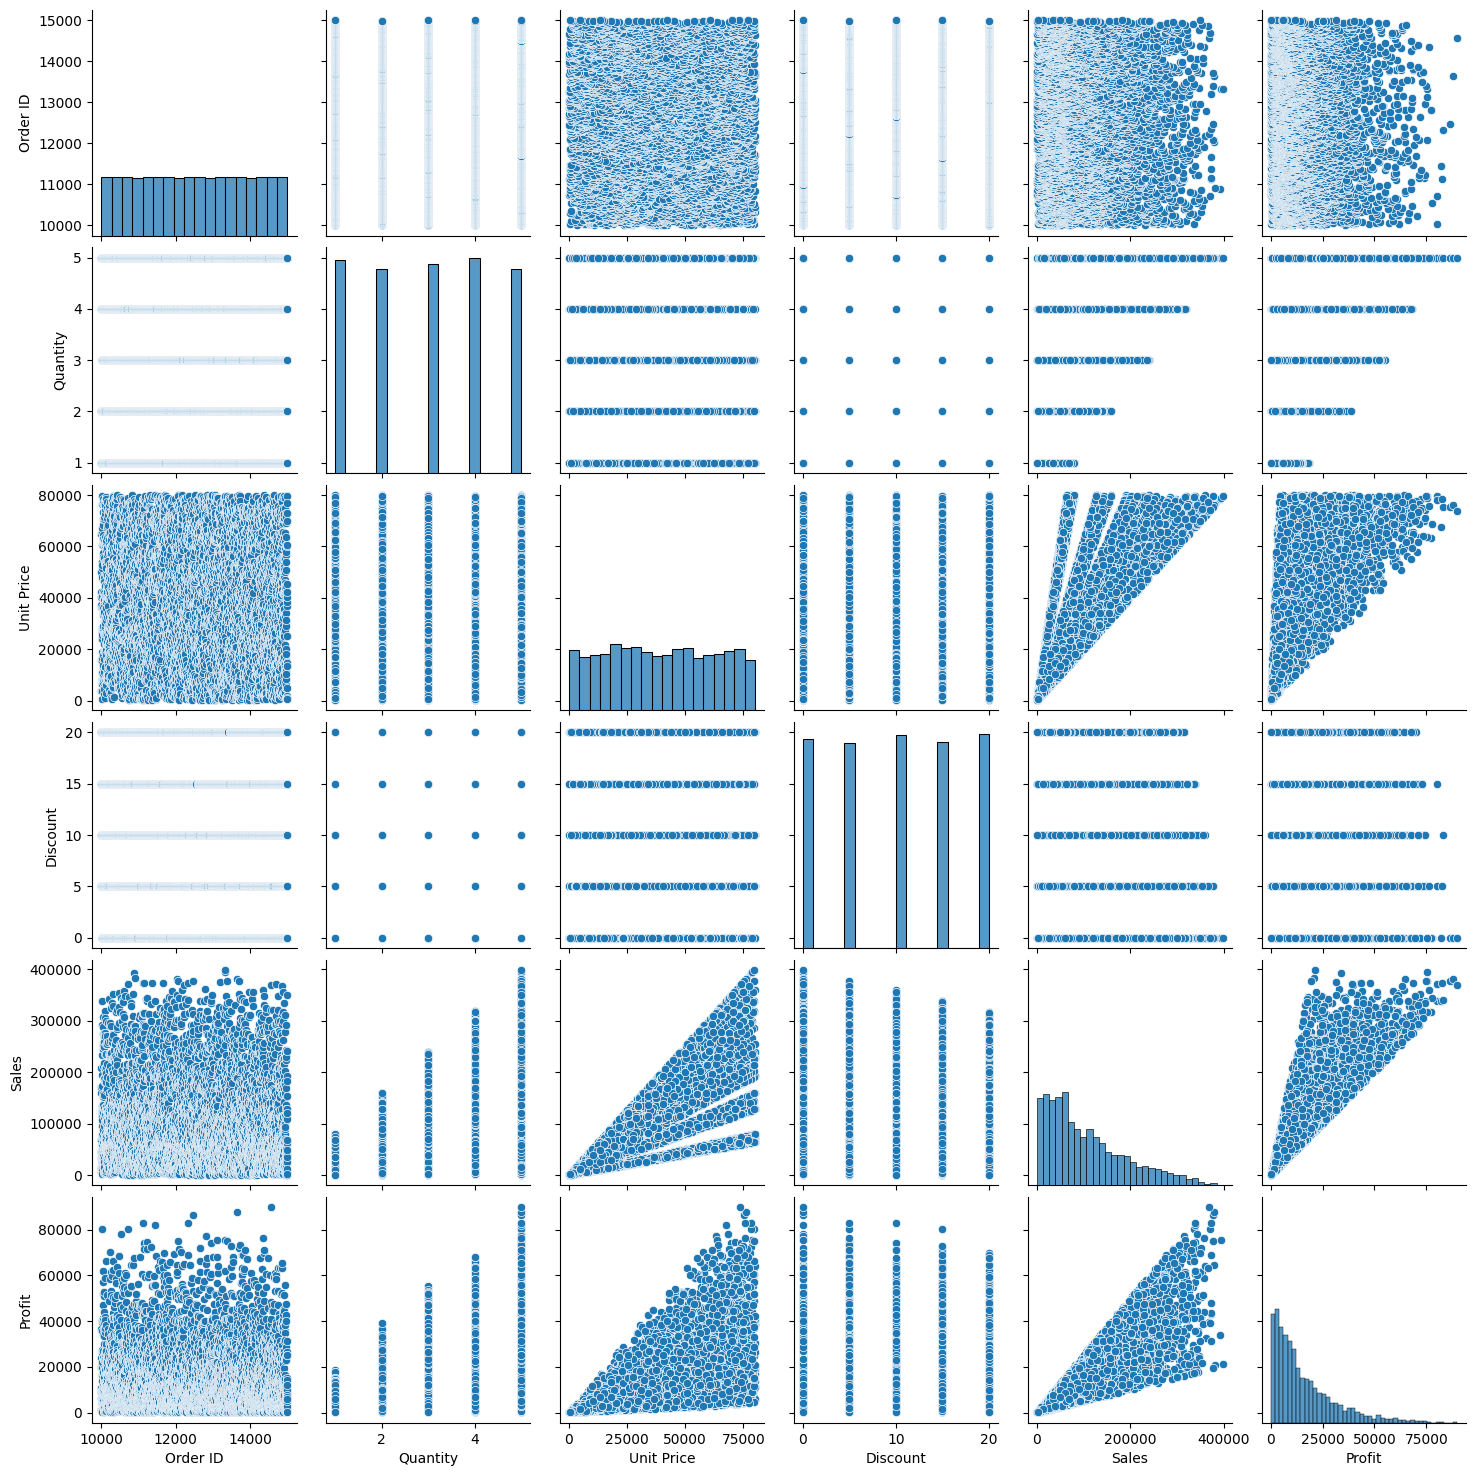

In [30]:
# Exploratory Data Analysis
sns.pairplot(df)
plt.show()
# Encode the non-numerical data 


Now let us plot charts to compare sales and profits across different categories

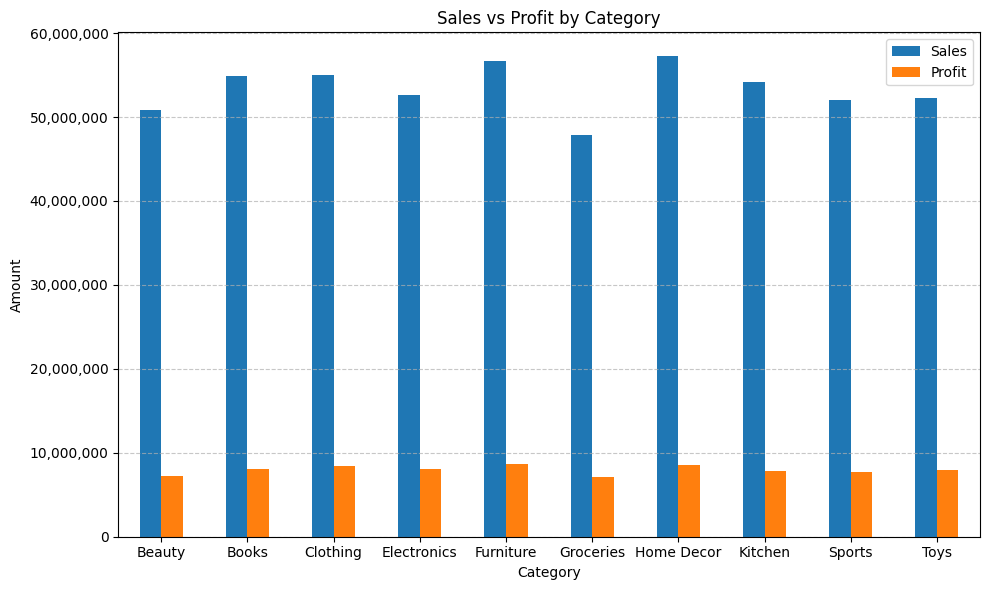

In [31]:
#Combined Sales and Profit Chart
def format_currency(value, tick_number):
    return f'{value:,.0f}'
category_analysis = df.groupby('Category')[['Sales','Profit']].sum().reset_index()
category_analysis.plot(x='Category', y=['Sales', 'Profit'], kind='bar', figsize=(10, 6))
plt.title('Sales vs Profit by Category')
plt.ylabel('Amount')
plt.gca().yaxis.set_major_formatter(FuncFormatter(format_currency))
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_18440\3365723922.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlation_by_category = df.groupby('Category').apply(



Correlation between Profit and numerical variables by category:
Profit       Profit     Sales  Discount  Unit Price  Quantity
Category                                                     
Beauty          1.0  0.829636 -0.183539    0.585869  0.457808
Books           1.0  0.851020 -0.172968    0.607127  0.493590
Clothing        1.0  0.857302 -0.049227    0.625152  0.541824
Electronics     1.0  0.867725 -0.061658    0.616367  0.515000
Furniture       1.0  0.854665 -0.054654    0.592764  0.515102
Groceries       1.0  0.840302 -0.056486    0.620220  0.454179
Home Decor      1.0  0.849177 -0.102422    0.617148  0.542958
Kitchen         1.0  0.836699 -0.105460    0.540385  0.508112
Sports          1.0  0.841366 -0.055527    0.637050  0.495868
Toys            1.0  0.857558 -0.056264    0.622685  0.492040


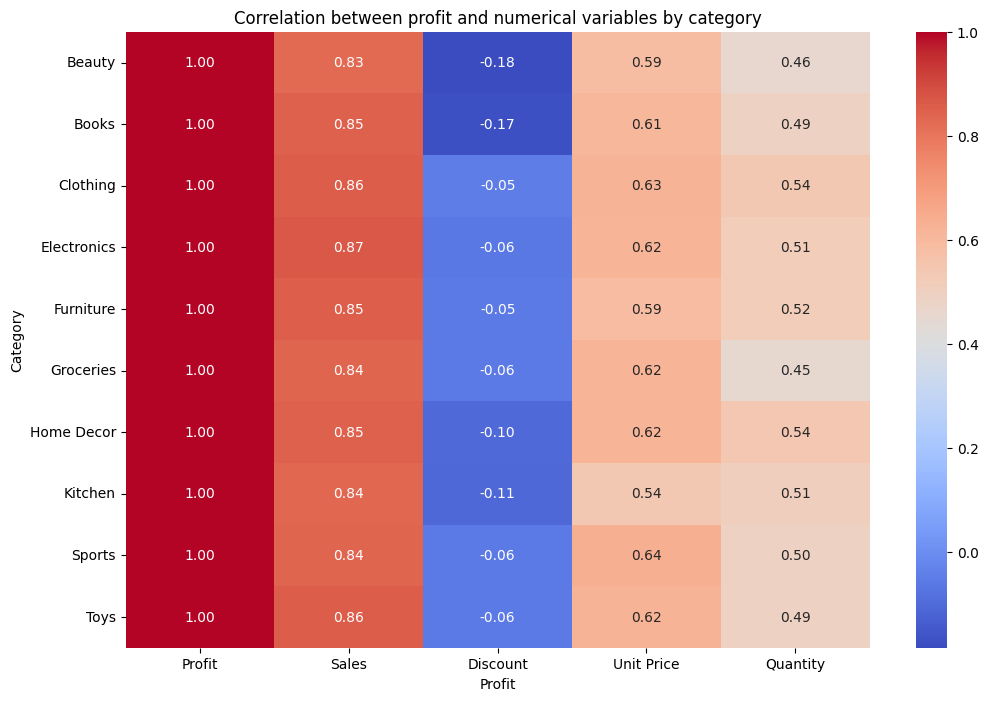

In [37]:
# Correlation between numerical features and profit
correlation_by_category = df.groupby('Category').apply(
    lambda x: x[['Profit', 'Sales', 'Discount', 'Unit Price', 'Quantity',  ]].corr()['Profit']
)
print("\nCorrelation between Profit and numerical variables by category:")
print(correlation_by_category)
# Use a heatmap to show the correlation
plt.figure(figsize=(12,8))
sns.heatmap(correlation_by_category, annot=True, cmap='coolwarm', fmt='.2f')
plt.title( 'Correlation between profit and numerical variables by category')
plt.show()



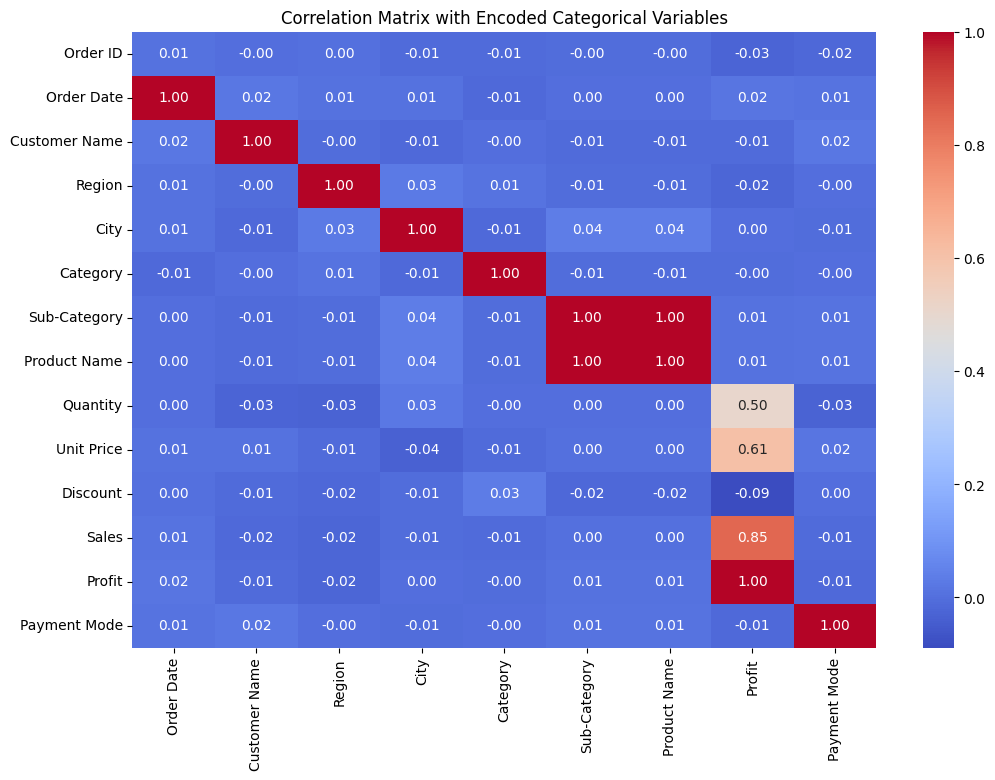

In [33]:
# Correlation between non-numerical features and profit
#One-hot encode Region and City for correlation analysis
df_encoded = df.copy()
label_encoder = LabelEncoder()  
for column in df_encoded.select_dtypes(include=['object']).columns:
    df_encoded[column] = label_encoder.fit_transform(df_encoded[column])
correlation_matrix_encoded = df_encoded.corr().drop(['Order ID', 'Unit Price', 'Discount', 'Sales', 'Quantity'], axis=1)
# Show correlation using a heatmap
plt.figure(figsize=(12,8))
sns.heatmap(correlation_matrix_encoded, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix with Encoded Categorical Variables')
plt.show()

From the correlation analysis we realize that profit has a very weak correlation to non-numerical features compared to numerical.
We will use the numerical features to predict profit using a linear regression model. we can add some numerical features to predict profit such as Region.

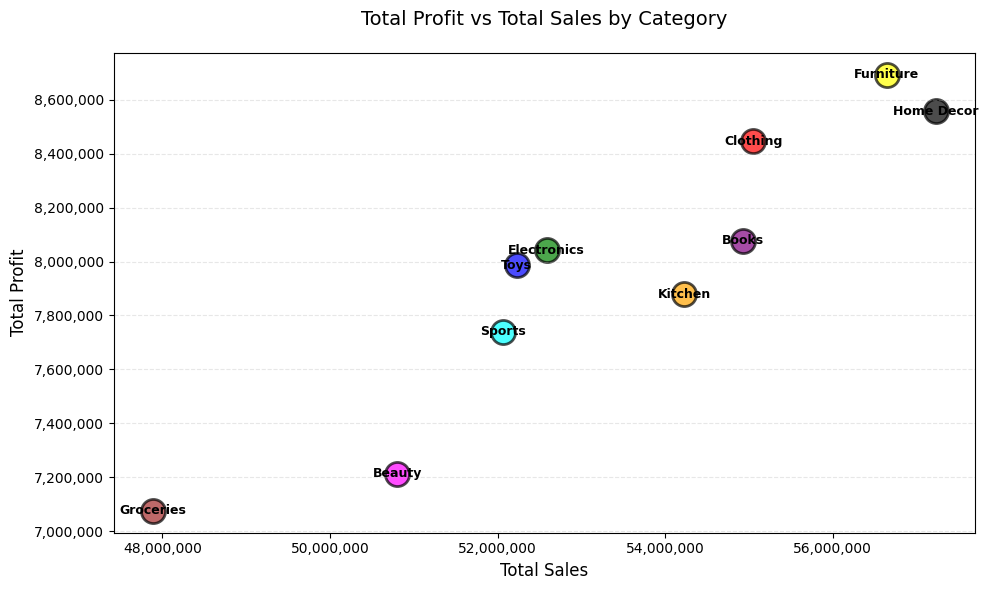

In [34]:
# Scatter plot: Total Sales vs Total Profit by Category
import matplotlib.pyplot as plt
# Sort by total sales (highest to lowest)
category_analysis_sorted = category_analysis.sort_values('Sales', ascending=False)
colors = ['black', 'yellow', 'red', 'purple', 'orange', 'green', 'blue', 'cyan', 'magenta', 'brown']
plt.figure(figsize=(10, 6))
for i, (idx, row) in enumerate(category_analysis_sorted.iterrows()):
    plt.scatter(row['Sales'], row['Profit'], 
               s=300, color=colors[i], alpha=0.7, edgecolors='black', linewidth=2)
    plt.annotate(row['Category'], (row['Sales'], row['Profit']), 
                ha='center', va='center', fontweight='bold', fontsize=9)

plt.title('Total Profit vs Total Sales by Category', fontsize=14, pad=20)
plt.xlabel('Total Sales', fontsize=12)
plt.ylabel('Total Profit', fontsize=12)
plt.gca().xaxis.set_major_formatter(FuncFormatter(format_currency))
plt.gca().yaxis.set_major_formatter(FuncFormatter(format_currency))
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.subplots_adjust(left=0.12, right=0.95, top=0.93, bottom=0.12)
plt.tight_layout()
plt.show()

According to the scatter plot, we realize that home decor is the best selling category but does not make the highest profit.
      On the other hand, the furniture category has the highest profit yet it is not the best selling 
        This indicates that there must be a factor that affects the profit of the sales made based on each category.
Let us build a linear regression model to predict the profit based on the sales, discount, City, Region for each category.

# Predictive Model


MODEL EVALUATION
Root Mean Squared Error: 7918.36
R-squared: 0.72
Model Intercept: -593.23
REGRESSION EQUATION
Profit = -593.2343 + 0.148429 * Sales - 6.323953 * Discount + 48.769816 * Quantity + 708.526832 * Category_Books + 1264.116487 * Category_Clothing + 1276.998586 * Category_Electronics + 1247.482478 * Category_Furniture + 414.610151 * Category_Groceries + 726.280323 * Category_Home Decor + 319.175406 * Category_Kitchen + 659.229128 * Category_Sports + 1200.457324 * Category_Toys - 251.488373 * Region_North - 171.702298 * Region_South - 87.136773 * Region_West
R² Score (Train): 0.7208
R² Score (Test): 0.7226
PREDICTION ON NEW DATA
Input: Sales=$500, Discount=10%, Quantity=5, Category=Home Decor, Region= North
Predicted Profit: $198.99


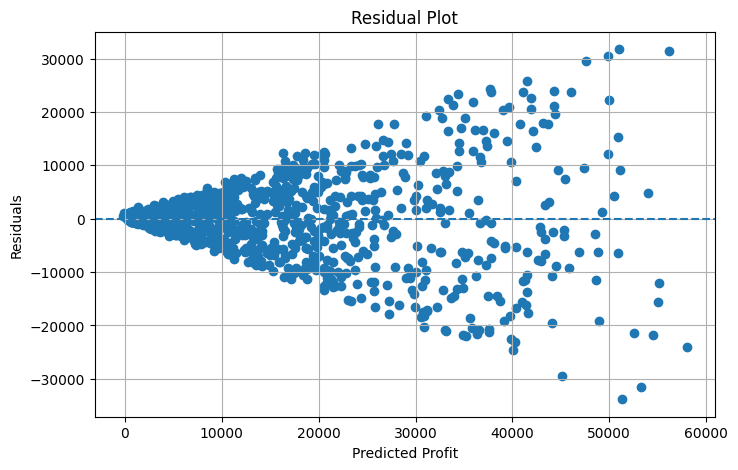

In [36]:
# Prepare the data
X = df[['Sales', 'Discount', 'Quantity', 'Category', 'Region',]]
# One-hot encode the 'Category' variable
X = pd.get_dummies(X, columns=['Category'], drop_first=True)
# One-hot encode the 'Region' variable
X = pd.get_dummies(X, columns=['Region'], drop_first=True)
y = df['Profit']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("MODEL EVALUATION")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R-squared: {r2:.2f}")
print(f"Model Intercept: {model.intercept_:.2f}")

# Display the equation
print("REGRESSION EQUATION")
print(f"Profit = {model.intercept_:.4f}", end="")
for i, coef in enumerate(model.coef_):
    var_name = X_train.columns[i]
    sign = "+" if coef >= 0 else "-"
    print(f" {sign} {abs(coef):.6f} * {var_name}", end="")
print()
print(f"R² Score (Train): {model.score(X_train, y_train):.4f}")
print(f"R² Score (Test): {model.score(X_test, y_test):.4f}")

# Predict the profit of new data
print("PREDICTION ON NEW DATA")
new_data = pd.DataFrame({
    'Sales': [500],
    'Discount': [0.1],
    'Quantity': [5],
    'Region_East': [0],
    'Region_West': [0],
    'Region_South': [0],
    'Region_North': [1],
    'Category_Furniture': [0],
    'Category_Home Decor': [1],
    'Category_Sports': [0],
    'Category_Clothing': [0],
    'Category_Toys': [0],
    'Category_Books': [0],
    'Category_Electronics': [0],
    'Category_Groceries': [0],
    'Category_Kitchen': [0]
})
# Ensure columns match X_train exactly
new_data = new_data[X_train.columns]
predicted_profit = model.predict(new_data)
print(f"Input: Sales=$500, Discount=10%, Quantity=5, Category=Home Decor, Region= North")
print(f"Predicted Profit: ${predicted_profit[0]:.2f}")
# Residual 
residuals= y_test-y_pred
plt.figure(figsize= (8,5))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, linestyle='--')
plt.title("Residual Plot")
plt.xlabel("Predicted Profit")
plt.ylabel("Residuals")
plt.grid(True)
plt.show()
